1. Intalling Libraries

In [ ]:
!pip install opencv-python matplotlib numpy

2. Video

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving svideo.mp4 to svideo.mp4


3. Creating Folders

In [ ]:
import os

os.makedirs("frames", exist_ok=True)
os.makedirs("compressed", exist_ok=True)

4. Frame Extraction

In [ ]:
import cv2

video_path = "svideo.mp4"

cap = cv2.VideoCapture(video_path)

count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    cv2.imwrite(f"frames/frame_{count}.jpg", frame)

    count += 1

cap.release()

print("Frames extracted:", count)

Frames extracted: 305


5. Compression

In [ ]:
import os
import cv2

files = sorted([f for f in os.listdir("frames") if f.endswith(".jpg")])

for f in files:

    img = cv2.imread(f"frames/{f}")

    resized = cv2.resize(img, (224,224))

    cv2.imwrite(
        f"compressed/{f}",
        resized,
        [cv2.IMWRITE_JPEG_QUALITY,60]
    )

print("Frames compressed:", len(files))

Frames compressed: 305


6. Frame Reduction Experiment

In [ ]:
import numpy as np

def frame_reduction(threshold):

    files = sorted([f for f in os.listdir("compressed") if f.endswith(".jpg")])

    prev_frame = None
    selected_frames= []

    for f in files:

        img = cv2.imread(f"compressed/{f}")
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        if prev_frame is None:
            prev_frame = gray
            selected_frames.append(f)
            continue

        diff = cv2.absdiff(prev_frame, gray)
        score = np.mean(diff)

        #print(score)

        if score > threshold:
            selected_frames.append(f)
            prev_frame = gray

    return selected_frames


threshold_values = [0.5, 1, 2, 5]
results = []

for t in threshold_values:

    kept = frame_reduction(t)

    print(f"Threshold {t} → Frames kept: {kept}")

    results.append(kept)



Threshold 0.5 → Frames kept: ['frame_0.jpg', 'frame_1.jpg', 'frame_10.jpg', 'frame_100.jpg', 'frame_101.jpg', 'frame_102.jpg', 'frame_103.jpg', 'frame_104.jpg', 'frame_105.jpg', 'frame_106.jpg', 'frame_107.jpg', 'frame_108.jpg', 'frame_109.jpg', 'frame_11.jpg', 'frame_110.jpg', 'frame_112.jpg', 'frame_113.jpg', 'frame_114.jpg', 'frame_115.jpg', 'frame_116.jpg', 'frame_117.jpg', 'frame_118.jpg', 'frame_119.jpg', 'frame_12.jpg', 'frame_120.jpg', 'frame_121.jpg', 'frame_122.jpg', 'frame_123.jpg', 'frame_124.jpg', 'frame_126.jpg', 'frame_127.jpg', 'frame_128.jpg', 'frame_129.jpg', 'frame_13.jpg', 'frame_130.jpg', 'frame_131.jpg', 'frame_132.jpg', 'frame_133.jpg', 'frame_134.jpg', 'frame_135.jpg', 'frame_136.jpg', 'frame_137.jpg', 'frame_138.jpg', 'frame_139.jpg', 'frame_14.jpg', 'frame_140.jpg', 'frame_142.jpg', 'frame_143.jpg', 'frame_144.jpg', 'frame_145.jpg', 'frame_146.jpg', 'frame_147.jpg', 'frame_148.jpg', 'frame_149.jpg', 'frame_15.jpg', 'frame_150.jpg', 'frame_151.jpg', 'frame_152.

Running it for one Threshold

In [ ]:
selected = frame_reduction(5)

print("Frames selected:", len(selected))

Frames selected: 63


Selected Frames

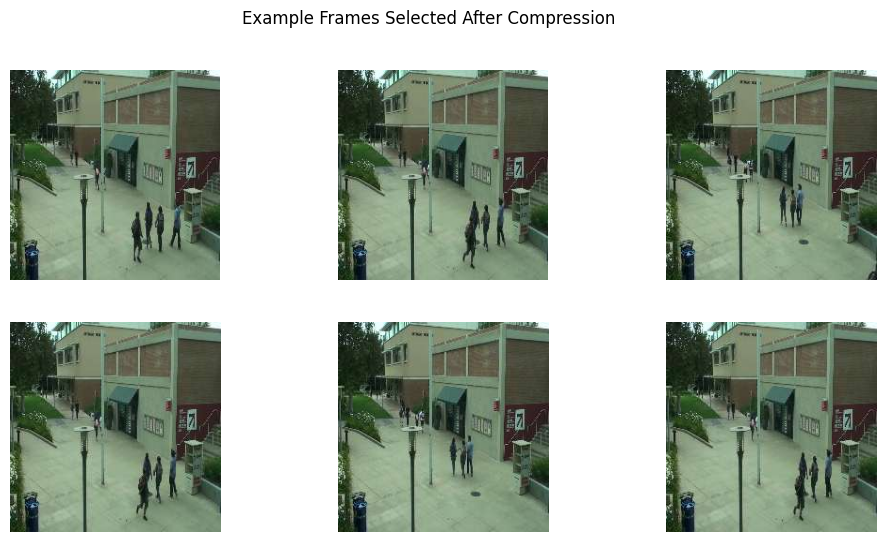

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(min(6, len(selected))):

    img = cv2.imread(f"compressed/{selected[i]}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Example Frames Selected After Compression")

plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

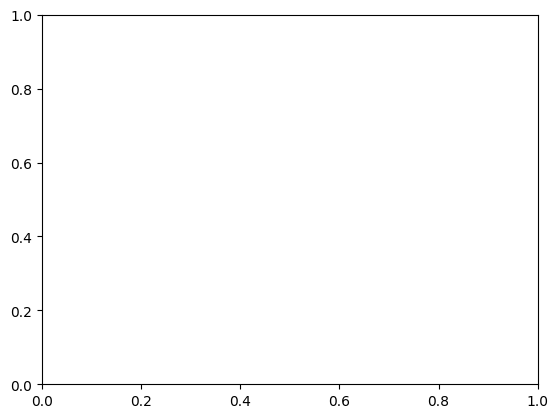

In [ ]:
import matplotlib.pyplot as plt

plt.plot(threshold_values, results, marker='o')

plt.xlabel("Threshold")
plt.ylabel("Frames Retained")
plt.title("Frame Reduction vs Threshold")

plt.show()